# FastGAN + DiffAugment — NEU Surface Defect Synthesis

**Goal:** Train one FastGAN per defect class to generate synthetic training images.  
**Hardware:** Kaggle P100 (16 GB VRAM). Each class trains in ~2–4 hours.  
**Dataset:** NEU Surface Defect Dataset (1800 images, 6 classes, ~300/class)

### Classes
| ID | Class | Typical appearance |
|---|---|---|
| 0 | `Cr` — Crazing | dense network of surface cracks |
| 1 | `In` — Inclusion | embedded foreign particles |
| 2 | `Pa` — Patches | irregular rough patches |
| 3 | `PS` — Pitted surface | pits / holes |
| 4 | `RS` — Rolled-in scale | scale pressed into surface |
| 5 | `Sc` — Scratches | linear scratch marks |

### Pipeline
```
NEU images → FastGAN per class (+ DiffAugment) → synthetic images → merge with real → downstream classifier
```

## Cell 1 — Install dependencies

In [1]:
%%capture
!pip install lpips==0.1.4 pytorch-fid==0.3.0

print('Dependencies installed.')


## Cell 2 — Download NEU Surface Defect dataset via KaggleHub

In [2]:
import kagglehub
import shutil, os, glob
from pathlib import Path

# Download — works natively inside Kaggle notebooks (no API key needed)
raw_path = kagglehub.dataset_download('kaustubhdikshit/neu-surface-defect-database')
print(f'Downloaded to: {raw_path}')

# Inspect what we got
for root, dirs, files in os.walk(raw_path):
    level = root.replace(raw_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  {f}')

Downloaded to: /kaggle/input/datasets/kaustubhdikshit/neu-surface-defect-database
neu-surface-defect-database/
  NEU-DET/
    validation/
      annotations/
      images/
        inclusion/
        scratches/
        pitted_surface/
        patches/
        crazing/
        rolled-in_scale/
    train/
      annotations/
      images/
        inclusion/
        scratches/
        pitted_surface/
        patches/
        crazing/
        rolled-in_scale/


## Cell 3 — Organise dataset into per-class folders

In [3]:
from pathlib import Path
import shutil, glob

DATA_ROOT   = Path('data/neu_defects')        # organised data lives here
SYNTH_ROOT  = Path('data/synthetic')          # generated images land here
CKPT_ROOT   = Path('checkpoints')             # model weights per class
LOG_ROOT    = Path('logs')                    # FID / loss logs per class

CLASS_NAMES = ['Cr', 'In', 'Pa', 'PS', 'RS', 'Sc']

for cls in CLASS_NAMES:
    (DATA_ROOT  / cls).mkdir(parents=True, exist_ok=True)
    (SYNTH_ROOT / cls).mkdir(parents=True, exist_ok=True)
    (CKPT_ROOT  / cls).mkdir(parents=True, exist_ok=True)
    (LOG_ROOT   / cls).mkdir(parents=True, exist_ok=True)

# NEU dataset images are named like Cr_1.bmp, In_23.bmp, etc.
# Adjust the glob pattern below if your download has a different structure.
all_images = glob.glob(str(raw_path) + '/**/*.bmp', recursive=True) + \
             glob.glob(str(raw_path) + '/**/*.jpg', recursive=True) + \
             glob.glob(str(raw_path) + '/**/*.png', recursive=True)

print(f'Total images found: {len(all_images)}')

counts = {c: 0 for c in CLASS_NAMES}
# Map the dataset's folder names to your class abbreviations
folder_map = {
    'crazing': 'Cr',
    'inclusion': 'In',
    'patches': 'Pa',
    'pitted_surface': 'PS',
    'rolled-in_scale': 'RS',
    'scratches': 'Sc'
}

for img_path in all_images:
    # Get the name of the folder containing the image
    parent_folder = Path(img_path).parent.name
    
    # Check if this folder is one of our defect classes
    if parent_folder in folder_map:
        cls = folder_map[parent_folder]
        fname = Path(img_path).name
        dst = DATA_ROOT / cls / fname
        
        if not dst.exists():
            shutil.copy2(img_path, dst)
        counts[cls] += 1

print('\nImages per class:')
for cls, n in counts.items():
    print(f'  {cls}: {n}')

Total images found: 1800

Images per class:
  Cr: 300
  In: 300
  Pa: 300
  PS: 300
  RS: 300
  Sc: 300


## Cell 4 — DiffAugment definition

DiffAugment applies random augmentations **inside the computational graph** so gradients flow through them. This stabilises discriminator training on small datasets by making it harder to memorise individual samples.

In [4]:
import torch
import torch.nn.functional as F


def DiffAugment(x, policy='color,translation,cutout'):
    if policy:
        for p in policy.split(','):
            p = p.strip()
            if not p:
                continue
            for f in AUGMENT_FNS[p]:
                x = f(x)
    return x.contiguous()


def rand_brightness(x):
    return x + (torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype) - 0.5)


def rand_saturation(x):
    x_mean = x.mean(dim=1, keepdim=True)
    scale = torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype) * 2
    return (x - x_mean) * scale + x_mean


def rand_contrast(x):
    x_mean = x.mean(dim=[1, 2, 3], keepdim=True)
    scale = torch.rand(x.size(0), 1, 1, 1, device=x.device, dtype=x.dtype) + 0.5
    return (x - x_mean) * scale + x_mean


def rand_translation(x, ratio=0.125):
    # Zero-padded translation avoids the wrap-around artifacts caused by torch.roll.
    b, c, h, w = x.shape
    shift_x = int(w * ratio + 0.5)
    shift_y = int(h * ratio + 0.5)
    if shift_x == 0 and shift_y == 0:
        return x

    translation_x = torch.randint(-shift_x, shift_x + 1, (b, 1, 1), device=x.device)
    translation_y = torch.randint(-shift_y, shift_y + 1, (b, 1, 1), device=x.device)

    grid_batch = torch.arange(b, device=x.device).view(b, 1, 1).expand(b, h, w)
    grid_y = torch.arange(h, device=x.device).view(1, h, 1).expand(b, h, w) + translation_y + shift_y
    grid_x = torch.arange(w, device=x.device).view(1, 1, w).expand(b, h, w) + translation_x + shift_x

    x_pad = F.pad(x, [shift_x, shift_x, shift_y, shift_y])
    out = x_pad.permute(0, 2, 3, 1).contiguous()[grid_batch, grid_y, grid_x]
    return out.permute(0, 3, 1, 2).contiguous()


def rand_cutout(x, ratio=0.5):
    b, c, h, w = x.shape
    cutout_h = int(h * ratio + 0.5)
    cutout_w = int(w * ratio + 0.5)
    offset_y = torch.randint(0, h, (b, 1, 1), device=x.device)
    offset_x = torch.randint(0, w, (b, 1, 1), device=x.device)

    grid_y = torch.arange(h, device=x.device).view(1, h, 1)
    grid_x = torch.arange(w, device=x.device).view(1, 1, w)
    keep_y = (grid_y - offset_y).abs() >= cutout_h // 2
    keep_x = (grid_x - offset_x).abs() >= cutout_w // 2
    mask = (keep_y | keep_x).unsqueeze(1).to(dtype=x.dtype)
    return x * mask


AUGMENT_FNS = {
    'color':       [rand_brightness, rand_saturation, rand_contrast],
    'translation': [rand_translation],
    'cutout':      [rand_cutout],
}

print('DiffAugment ready. Policy: color, translation, cutout')


DiffAugment ready. Policy: color, translation, cutout


## Cell 5 — FastGAN model definition

Self-contained implementation (no dependency on the cloned repo).  
Key components:
- **Generator:** noise → image via upsampling blocks with Skip-Layer Excitation (SLE)
- **Discriminator:** image → real/fake + self-supervised decoder head

In [5]:
import torch
import torch.nn as nn

# ─── Utility blocks ──────────────────────────────────────────────────────────

def NormAct(ch):
    """BatchNorm + LeakyReLU — used throughout."""
    return nn.Sequential(nn.BatchNorm2d(ch), nn.LeakyReLU(0.2, inplace=True))

class UpsampleBlock(nn.Module):
    """2× bilinear upsample → conv → norm+act."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch * 2),
            nn.GLU(dim=1),           # GLU halves channels: out_ch*2 → out_ch
        )
    def forward(self, x):
        return self.net(x)

class SLE(nn.Module):
    """
    Skip-Layer Excitation: the key FastGAN trick.
    Routes gradients from early (small) feature maps into late (large) ones
    so the generator learns coarse structure even on tiny datasets.
    low → global average pool → fc → sigmoid → multiply into high
    """
    def __init__(self, ch_low, ch_high):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(ch_low * 16, ch_high),
            nn.Sigmoid(),
        )
        self.ch_high = ch_high

    def forward(self, low, high):
        # low: early feature map (small spatial, many channels)
        # high: later feature map (large spatial, fewer channels)
        scale = self.se(low).view(-1, self.ch_high, 1, 1)
        return high * scale


# ─── Generator ───────────────────────────────────────────────────────────────

class Generator(nn.Module):
    """
    z (256-dim noise) → 128×128 RGB image.
    Architecture: linear → reshape → 5 upsample blocks.
    SLE connections: 8×8 → 64×64, 16×16 → 128×128.
    """
    def __init__(self, z_dim=256, ngf=64):
        super().__init__()
        self.z_dim = z_dim

        # Initial projection: noise → 4×4 feature map
        self.init = nn.Sequential(
            nn.Linear(z_dim, ngf * 16 * 4 * 4, bias=False),
            nn.Unflatten(1, (ngf * 16, 4, 4)),
            NormAct(ngf * 16),
        )  # → (B, ngf*16, 4, 4)

        self.up1  = UpsampleBlock(ngf * 16, ngf * 8)   # → 8×8
        self.up2  = UpsampleBlock(ngf * 8,  ngf * 4)   # → 16×16
        self.up3  = UpsampleBlock(ngf * 4,  ngf * 2)   # → 32×32
        self.up4  = UpsampleBlock(ngf * 2,  ngf)        # → 64×64
        self.up5  = UpsampleBlock(ngf,      ngf // 2)   # → 128×128

        # SLE: feature map at 8×8 excites 64×64
        self.sle1 = SLE(ngf * 8, ngf)
        # SLE: feature map at 16×16 excites 128×128
        self.sle2 = SLE(ngf * 4, ngf // 2)

        # Output head: → 3-channel image in [-1, 1]
        self.to_rgb = nn.Sequential(
            nn.Conv2d(ngf // 2, 3, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        x  = self.init(z)
        x1 = self.up1(x)           # 8×8,  ngf*8
        x2 = self.up2(x1)          # 16×16, ngf*4
        x3 = self.up3(x2)          # 32×32, ngf*2
        x4 = self.up4(x3)          # 64×64, ngf
        x4 = self.sle1(x1, x4)     # SLE excitation
        x5 = self.up5(x4)          # 128×128, ngf//2
        x5 = self.sle2(x2, x5)     # SLE excitation
        return self.to_rgb(x5)


# ─── Discriminator ───────────────────────────────────────────────────────────

class DownBlock(nn.Module):
    """2× stride conv → norm + leakyrelu."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    """
    Dual-purpose:
      1. Real / fake classification (standard GAN loss)
      2. Self-supervised decoder head: reconstruct a random crop of a real image
         from the intermediate features. This gives the discriminator much richer
         gradient signal per image — crucial for small datasets.
    """
    def __init__(self, ndf=64):
        super().__init__()

        # Encoder backbone: 128×128 → 4×4
        self.enc = nn.Sequential(
            DownBlock(3,        ndf),        # 64×64
            DownBlock(ndf,      ndf * 2),    # 32×32
            DownBlock(ndf * 2,  ndf * 4),    # 16×16
            DownBlock(ndf * 4,  ndf * 8),    # 8×8
            DownBlock(ndf * 8,  ndf * 16),   # 4×4
        )

        # Real / fake head
        self.cls = nn.Sequential(
            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),  # → scalar
        )

        # Self-supervised decoder head: reconstructs 32×32 crop from 4×4 features
        self.dec = nn.Sequential(
            UpsampleBlock(ndf * 16, ndf * 8),   # 8×8
            UpsampleBlock(ndf * 8,  ndf * 4),   # 16×16
            UpsampleBlock(ndf * 4,  ndf * 2),   # 32×32
            nn.Conv2d(ndf * 2, 3, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, x):
        feat = self.enc(x)
        logit = self.cls(feat).view(-1)
        recon = self.dec(feat)        # 32×32 reconstruction
        return logit, recon


# ─── Sanity check ────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

G = Generator().to(device)
D = Discriminator().to(device)

z_test = torch.randn(4, 256, device=device)
fake   = G(z_test)
logits, recon = D(fake)

g_params = sum(p.numel() for p in G.parameters()) / 1e6
d_params = sum(p.numel() for p in D.parameters()) / 1e6

print(f'Generator output:     {fake.shape}')    # (4, 3, 128, 128)
print(f'Discriminator logits: {logits.shape}')  # (4,)
print(f'Decoder recon:        {recon.shape}')   # (4, 3, 32, 32)
print(f'Generator params:     {g_params:.1f}M')
print(f'Discriminator params: {d_params:.1f}M')

Device: cuda
Generator output:     torch.Size([4, 3, 128, 128])
Discriminator logits: torch.Size([4])
Decoder recon:        torch.Size([4, 3, 32, 32])
Generator params:     17.4M
Discriminator params: 23.6M


## Cell 6 — Dataset & DataLoader

In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random
import torch

IMG_SIZE = 128  # FastGAN target resolution


class DefectDataset(Dataset):
    """
    Loads all images from a single class folder.
    Returns tensors in [-1, 1] (tanh range, matching Generator output).
    """
    EXTS = {'.bmp', '.jpg', '.jpeg', '.png'}

    def __init__(self, folder, img_size=128, max_images=None, seed=42):
        self.paths = sorted(
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in self.EXTS
        )
        assert len(self.paths) > 0, f'No images found in {folder}'
        if max_images is not None and max_images < len(self.paths):
            rng = random.Random(seed)
            rng.shuffle(self.paths)
            self.paths = sorted(self.paths[:max_images])

        self.tf = transforms.Compose([
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.LANCZOS),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return self.tf(Image.open(self.paths[idx]).convert('RGB'))


def make_loader(class_name, batch_size=16, max_images=None, seed=42, num_workers=2):
    folder = DATA_ROOT / class_name
    dataset = DefectDataset(folder, IMG_SIZE, max_images=max_images, seed=seed)
    assert len(dataset) >= batch_size, (
        f'Only {len(dataset)} images selected for {class_name}; reduce batch_size.'
    )

    loader_kwargs = dict(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True,
    )
    if num_workers > 0:
        loader_kwargs['persistent_workers'] = True

    loader = DataLoader(**loader_kwargs)
    print(f'Class {class_name}: {len(dataset)} images, {len(loader)} batches/epoch')
    return loader


# Quick test
_test_loader = make_loader('Cr', batch_size=16)
_sample_batch = next(iter(_test_loader))
print(f'Batch shape: {_sample_batch.shape}, range: [{_sample_batch.min():.2f}, {_sample_batch.max():.2f}]')


Class Cr: 300 images, 18 batches/epoch
Batch shape: torch.Size([16, 3, 128, 128]), range: [-0.82, 1.00]


## Cell 7 — Training loop

Loss structure:
- **D loss** = hinge real/fake + λ_rec × L1 reconstruction loss on real image crops
- **G loss** = hinge adversarial only (standard)
- DiffAugment applied to **both** real and fake before discriminator

In [7]:
import copy
import json
import math
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torchvision.utils import save_image


# Config tuned for a Kaggle free GPU session. Auto epochs target roughly 30k GAN steps,
# then stop gracefully around 4.5 hours if the GPU is slower than expected.
CFG = {
    'z_dim':          256,
    'ngf':            64,
    'ndf':            64,
    'lr_g':           2e-4,
    'lr_d':           2e-4,
    'beta1':          0.0,
    'beta2':          0.99,
    'batch_size':     16,
    'n_epochs':       'auto',       # or set an integer manually
    'target_steps':   30000,
    'min_epochs':     200,
    'max_epochs':     2000,
    'max_minutes':    270,          # 4.5 hours, leaves Kaggle shutdown margin
    'max_images':     None,         # set 300/500/1000 to cap per-class training images
    'lambda_rec':     0.10,
    'aug_policy':     'color,translation,cutout',
    'amp':            True,
    'ema':            True,
    'ema_decay':      0.995,
    'save_every':     50,
    'sample_every':   25,
    'print_every':    10,
    'n_sample':       16,
    'seed':           42,
    'resume':         True,
}


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True


def hinge_d_loss(real_logits, fake_logits):
    return F.relu(1. - real_logits).mean() + F.relu(1. + fake_logits).mean()


def hinge_g_loss(fake_logits):
    return -fake_logits.mean()


def set_requires_grad(model, flag):
    for p in model.parameters():
        p.requires_grad_(flag)


def update_ema(ema_model, model, decay):
    with torch.no_grad():
        for p_ema, p in zip(ema_model.parameters(), model.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)
        for b_ema, b in zip(ema_model.buffers(), model.buffers()):
            b_ema.copy_(b)


def resolve_total_epochs(cfg, steps_per_epoch):
    if cfg['n_epochs'] == 'auto':
        epochs = math.ceil(cfg['target_steps'] / max(1, steps_per_epoch))
        epochs = max(cfg['min_epochs'], epochs)
        return min(cfg['max_epochs'], epochs)
    return int(cfg['n_epochs'])


def unpack_real(batch):
    return batch[0] if isinstance(batch, (tuple, list)) else batch


# Main training function

def train_class(class_name, cfg=CFG, device='cuda'):
    seed_everything(cfg.get('seed', 42))
    device = torch.device(device if torch.cuda.is_available() else 'cpu')

    banner = '=' * 60
    print(f'\n{banner}')
    print(f'  Training FastGAN on class: {class_name}')
    print(f'{banner}\n')

    ckpt_dir = CKPT_ROOT / class_name
    sample_dir = Path('samples') / class_name
    log_path = LOG_ROOT / class_name / 'losses.json'
    sample_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_path.parent.mkdir(parents=True, exist_ok=True)

    G = Generator(cfg['z_dim'], cfg['ngf']).to(device)
    D = Discriminator(cfg['ndf']).to(device)
    G_ema = copy.deepcopy(G).eval()
    set_requires_grad(G_ema, False)

    opt_G = torch.optim.Adam(G.parameters(), lr=cfg['lr_g'], betas=(cfg['beta1'], cfg['beta2']))
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg['lr_d'], betas=(cfg['beta1'], cfg['beta2']))

    loader = make_loader(
        class_name=class_name,
        batch_size=cfg['batch_size'],
        max_images=cfg.get('max_images'),
        seed=cfg.get('seed', 42),
    )
    total_epochs = resolve_total_epochs(cfg, len(loader))
    print(f'Training schedule: {total_epochs} epochs x {len(loader)} batches = ~{total_epochs * len(loader)} steps')

    fixed_z = torch.randn(cfg['n_sample'], cfg['z_dim'], device=device)
    history = {'epoch': [], 'g_loss': [], 'd_loss': []}
    start_epoch = 1
    latest_ckpt = ckpt_dir / 'latest.pt'

    if cfg.get('resume', True) and latest_ckpt.exists():
        state = torch.load(latest_ckpt, map_location=device)
        G.load_state_dict(state['G'])
        D.load_state_dict(state['D'])
        if 'G_ema' in state:
            G_ema.load_state_dict(state['G_ema'])
        else:
            G_ema.load_state_dict(state['G'])
        opt_G.load_state_dict(state['opt_G'])
        opt_D.load_state_dict(state['opt_D'])
        fixed_z = state.get('fixed_z', fixed_z).to(device)
        start_epoch = int(state['epoch']) + 1
        history = state.get('history', history)
        print(f'Resumed from epoch {state["epoch"]}')

    amp_enabled = bool(cfg.get('amp', True) and device.type == 'cuda')
    scaler_G = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    scaler_D = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    print(f'Device: {device}; AMP: {amp_enabled}; EMA: {cfg.get("ema", True)}')

    t0 = time.time()
    last_epoch = start_epoch - 1

    for epoch in range(start_epoch, total_epochs + 1):
        G.train()
        D.train()
        ep_g, ep_d = 0.0, 0.0

        for batch in loader:
            real = unpack_real(batch).to(device, non_blocking=True)
            b = real.size(0)

            opt_D.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                z = torch.randn(b, cfg['z_dim'], device=device)
                fake = G(z).detach()
                real_aug = DiffAugment(real, cfg['aug_policy'])
                fake_aug = DiffAugment(fake, cfg['aug_policy'])
                real_logits, real_recon = D(real_aug)
                fake_logits, _ = D(fake_aug)
                loss_adv = hinge_d_loss(real_logits, fake_logits)
                real_aug_down = F.interpolate(real_aug, size=32, mode='area')
                loss_rec = F.l1_loss(real_recon, real_aug_down)
                loss_D = loss_adv + cfg['lambda_rec'] * loss_rec
            scaler_D.scale(loss_D).backward()
            scaler_D.step(opt_D)
            scaler_D.update()

            opt_G.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                z = torch.randn(b, cfg['z_dim'], device=device)
                fake = G(z)
                fake_aug = DiffAugment(fake, cfg['aug_policy'])
                fake_logits, _ = D(fake_aug)
                loss_G = hinge_g_loss(fake_logits)
            scaler_G.scale(loss_G).backward()
            scaler_G.step(opt_G)
            scaler_G.update()

            if cfg.get('ema', True):
                update_ema(G_ema, G, cfg['ema_decay'])

            ep_g += float(loss_G.detach().cpu())
            ep_d += float(loss_D.detach().cpu())

        ep_g /= len(loader)
        ep_d /= len(loader)
        elapsed = (time.time() - t0) / 60
        last_epoch = epoch

        history['epoch'].append(epoch)
        history['g_loss'].append(ep_g)
        history['d_loss'].append(ep_d)

        if epoch % cfg['print_every'] == 0 or epoch == start_epoch:
            print(
                f'[{class_name}] Ep {epoch:4d}/{total_epochs} | '
                f'G={ep_g:.4f} D={ep_d:.4f} | {elapsed:.1f} min elapsed'
            )

        if epoch % cfg['sample_every'] == 0 or epoch == total_epochs:
            sample_model = G_ema if cfg.get('ema', True) else G
            sample_model.eval()
            with torch.no_grad():
                samples = sample_model(fixed_z).float().cpu() * 0.5 + 0.5
            save_image(samples.clamp(0, 1), sample_dir / f'epoch_{epoch:04d}.png', nrow=4)

        if epoch % cfg['save_every'] == 0:
            state = {
                'epoch': epoch,
                'G': G.state_dict(),
                'G_ema': G_ema.state_dict(),
                'D': D.state_dict(),
                'opt_G': opt_G.state_dict(),
                'opt_D': opt_D.state_dict(),
                'fixed_z': fixed_z.detach().cpu(),
                'history': history,
                'cfg': cfg,
            }
            torch.save(state, ckpt_dir / f'epoch_{epoch:04d}.pt')
            torch.save(state, latest_ckpt)
            log_path.write_text(json.dumps(history, indent=2))

        if cfg.get('max_minutes') and elapsed >= cfg['max_minutes']:
            print(f'Time budget reached at epoch {epoch}; saving final checkpoint now.')
            break

    final_state = {
        'epoch': last_epoch,
        'G': G.state_dict(),
        'G_ema': G_ema.state_dict(),
        'D': D.state_dict(),
        'opt_G': opt_G.state_dict(),
        'opt_D': opt_D.state_dict(),
        'fixed_z': fixed_z.detach().cpu(),
        'history': history,
        'cfg': cfg,
    }
    torch.save(final_state, ckpt_dir / 'final.pt')
    torch.save(final_state, latest_ckpt)
    log_path.write_text(json.dumps(history, indent=2))
    print(f'\nDone. Last epoch: {last_epoch}. Session time: {(time.time() - t0) / 60:.1f} min')
    return G_ema if cfg.get('ema', True) else G


## Cell 8 — Train one class (start here; run 6× for all classes)

Change `CLASS_TO_TRAIN` to iterate through all 6 classes.  
Each run fits within ~4 hours of P100 time at 500 epochs.

In [8]:
# ── Change this to train the next class ───────────────────────────────────────
CLASS_TO_TRAIN = 'Cr'     # options: 'Cr', 'In', 'Pa', 'PS', 'RS', 'Sc'
# ─────────────────────────────────────────────────────────────────────────────

assert CLASS_TO_TRAIN in CLASS_NAMES, f'Unknown class: {CLASS_TO_TRAIN}'
device = 'cuda' if torch.cuda.is_available() else 'cpu'

trained_G = train_class(CLASS_TO_TRAIN, cfg=CFG, device=device)



  Training FastGAN on class: Cr

Class Cr: 300 images, 18 batches/epoch
Training schedule: 1667 epochs x 18 batches = ~30006 steps
Device: cuda; AMP: True; EMA: True


/tmp/ipykernel_23/1343193748.py:143: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/tmp/ipykernel_23/1343193748.py:144: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = torch.cuda.amp.GradScaler(enabled=amp_enabled)
/tmp/ipykernel_23/1343193748.py:160: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):
/tmp/ipykernel_23/1343193748.py:176: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


[Cr] Ep    1/1667 | G=1.1328 D=2.8580 | 0.3 min elapsed
[Cr] Ep   10/1667 | G=4.0408 D=0.0216 | 0.6 min elapsed
[Cr] Ep   20/1667 | G=3.2259 D=0.0135 | 1.0 min elapsed
[Cr] Ep   30/1667 | G=4.6923 D=0.0244 | 1.5 min elapsed
[Cr] Ep   40/1667 | G=3.2610 D=0.0126 | 1.9 min elapsed
[Cr] Ep   50/1667 | G=5.4479 D=0.3699 | 2.4 min elapsed
[Cr] Ep   60/1667 | G=4.6017 D=0.0223 | 2.8 min elapsed
[Cr] Ep   70/1667 | G=4.4851 D=0.0126 | 3.3 min elapsed
[Cr] Ep   80/1667 | G=5.9117 D=0.0153 | 3.7 min elapsed
[Cr] Ep   90/1667 | G=6.1072 D=0.0118 | 4.1 min elapsed
[Cr] Ep  100/1667 | G=6.2420 D=0.0132 | 4.6 min elapsed
[Cr] Ep  110/1667 | G=6.4515 D=0.0108 | 5.1 min elapsed
[Cr] Ep  120/1667 | G=7.5957 D=0.0106 | 5.5 min elapsed
[Cr] Ep  130/1667 | G=10.9887 D=0.0190 | 5.9 min elapsed
[Cr] Ep  140/1667 | G=8.1526 D=0.0106 | 6.4 min elapsed
[Cr] Ep  150/1667 | G=9.8622 D=0.0726 | 6.8 min elapsed
[Cr] Ep  160/1667 | G=6.4362 D=0.0096 | 7.3 min elapsed
[Cr] Ep  170/1667 | G=8.5436 D=0.0106 | 7.7 min

## Cell 9 — Generate synthetic images for a trained class

In [9]:
import torch
from pathlib import Path
from PIL import Image
import numpy as np


def generate_synthetic(
    class_name,
    n_images=500,
    batch_size=64,
    device='cuda',
    checkpoint='final',     # 'final', 'latest', or 'epoch_0400'
    use_ema=True,
    clear_existing=True,
):
    """
    Load a trained generator and generate n_images synthetic samples.
    Saves individual PNGs to data/synthetic/<class_name>/.
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    ckpt_path = CKPT_ROOT / class_name / f'{checkpoint}.pt'
    assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'

    state = torch.load(ckpt_path, map_location=device)
    G = Generator(CFG['z_dim'], CFG['ngf']).to(device)
    weight_key = 'G_ema' if use_ema and 'G_ema' in state else 'G'
    G.load_state_dict(state[weight_key])
    G.eval()

    out_dir = SYNTH_ROOT / class_name
    out_dir.mkdir(parents=True, exist_ok=True)
    if clear_existing:
        for p in out_dir.glob(f'synth_{class_name}_*.png'):
            p.unlink()

    generated = 0
    print(f'Generating {n_images} images for class {class_name} from {weight_key}...')

    with torch.no_grad():
        while generated < n_images:
            bs = min(batch_size, n_images - generated)
            z = torch.randn(bs, CFG['z_dim'], device=device)
            imgs = (G(z).float().cpu() * 0.5 + 0.5).clamp(0, 1)

            for i, img in enumerate(imgs):
                arr = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
                Image.fromarray(arr).convert('L').save(
                    out_dir / f'synth_{class_name}_{generated + i:05d}.png'
                )
            generated += bs

    print(f'Saved {generated} images to {out_dir}')


# Generate for the class you just trained.
generate_synthetic(
    class_name=CLASS_TO_TRAIN,
    n_images=500,
    batch_size=64,
    device=device,
    checkpoint='final',
    use_ema=True,
)


Generating 500 images for class Cr from G_ema...
Saved 500 images to data/synthetic/Cr


## Cell 10 — FID evaluation per class

FID (Fréchet Inception Distance) measures distributional similarity between real and generated images.  
Lower is better. For industrial textures, FID < 80 is acceptable; < 50 is good.

In [10]:
import subprocess
import sys
import torch


def compute_fid(class_name):
    real_dir = DATA_ROOT / class_name
    fake_dir = SYNTH_ROOT / class_name
    assert real_dir.exists() and any(real_dir.glob('*')), f'No real images in {real_dir}'
    assert fake_dir.exists() and any(fake_dir.glob('*.png')), f'No synthetic images in {fake_dir}'

    device_arg = 'cuda' if torch.cuda.is_available() else 'cpu'
    result = subprocess.run(
        [sys.executable, '-m', 'pytorch_fid', str(real_dir), str(fake_dir),
         '--device', device_arg, '--num-workers', '2'],
        capture_output=True,
        text=True,
    )
    out = (result.stdout + '\n' + result.stderr).strip()
    try:
        return float(out.split('FID:')[-1].strip().split()[0])
    except Exception:
        print(f'Could not parse FID for {class_name}: {out}')
        return None


print(f'FID for {CLASS_TO_TRAIN}: ', end='')
fid_score = compute_fid(CLASS_TO_TRAIN)
print(f'{fid_score:.2f}' if fid_score is not None else 'Error')
print('Use FID as a rough sanity check only; visual quality and downstream real-data validation matter more.')


FID for Cr: 75.3
Use FID as a rough sanity check only; visual quality and downstream real-data validation matter more.


## Cell 11 — Visualise: real vs synthetic side-by-side

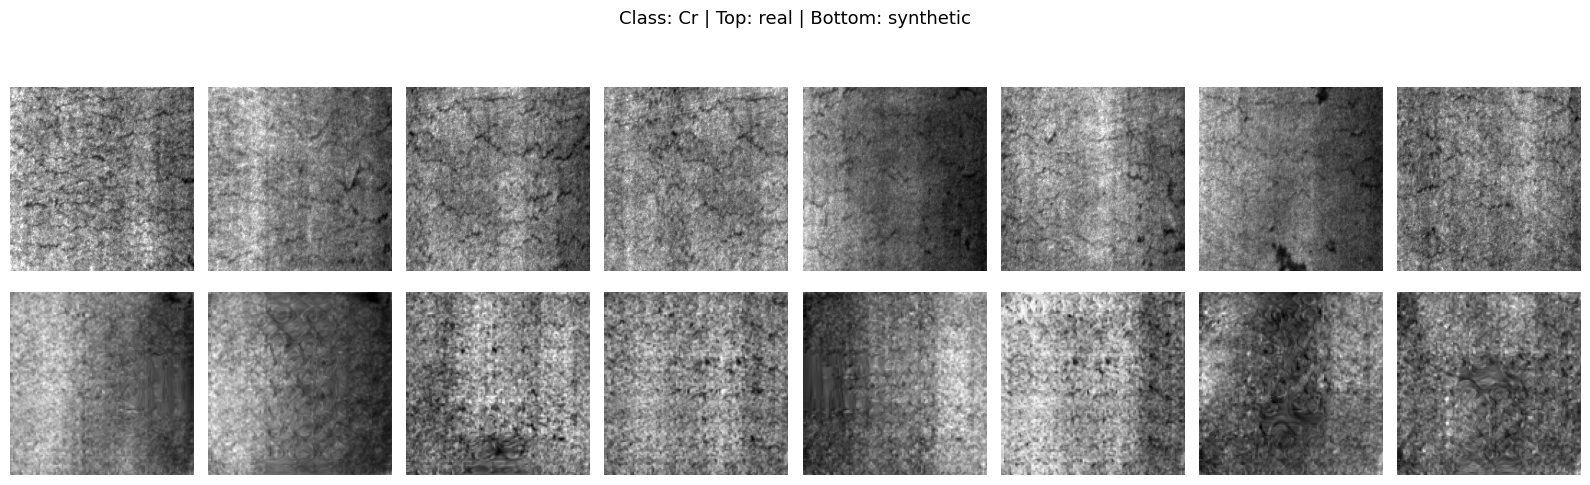

Saved comparison grid.


In [11]:
import glob
import random
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image


def visualise_class(class_name, n=8):
    real_paths = sorted(glob.glob(str(DATA_ROOT / class_name / '*')))[:n]
    synth_paths = sorted(glob.glob(str(SYNTH_ROOT / class_name / '*.png')))[:n]

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 5))
    fig.suptitle(f'Class: {class_name} | Top: real | Bottom: synthetic', fontsize=13, y=1.01)

    for i in range(n):
        if i < len(real_paths):
            axes[0, i].imshow(Image.open(real_paths[i]).convert('L'), cmap='gray')
        axes[0, i].axis('off')

        if i < len(synth_paths):
            axes[1, i].imshow(Image.open(synth_paths[i]).convert('L'), cmap='gray')
        axes[1, i].axis('off')

    Path('samples').mkdir(exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'samples/comparison_{class_name}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved comparison grid.')


visualise_class(CLASS_TO_TRAIN)


## Cell 12 — Build the augmented dataset for downstream training

After training all 6 classes, call this to create a merged real+synthetic dataset  
ready to drop into a YOLOv8 or ResNet training pipeline.

In [12]:
import random
import shutil
from pathlib import Path

AUGMENTED_ROOT = Path('data/augmented')   # final mixed dataset
SYNTH_RATIO = 0.35                        # 35% synthetic, 65% real
SEED = 42
random.seed(SEED)


def build_augmented_dataset(classes=CLASS_NAMES, synth_ratio=SYNTH_RATIO, reset=True):
    """
    For each class: copy all real images, then add enough synthetic images so
    synthetic samples are synth_ratio of the final folder.
    """
    summary = {}

    for cls in classes:
        out_dir = AUGMENTED_ROOT / cls
        if reset and out_dir.exists():
            shutil.rmtree(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

        real_imgs = sorted(p for p in (DATA_ROOT / cls).glob('*') if p.is_file())
        synth_imgs = sorted((SYNTH_ROOT / cls).glob('*.png'))
        n_real = len(real_imgs)
        n_synth = min(int(n_real * synth_ratio / (1 - synth_ratio)), len(synth_imgs))
        selected = random.sample(synth_imgs, n_synth) if n_synth else []

        for p in real_imgs:
            shutil.copy2(p, out_dir / p.name)
        for p in selected:
            shutil.copy2(p, out_dir / p.name)

        total = n_real + n_synth
        summary[cls] = {'real': n_real, 'synthetic': n_synth, 'total': total}
        print(f'  {cls}: {n_real} real + {n_synth} synthetic = {total} total')

    print(f'\nAugmented dataset written to: {AUGMENTED_ROOT}')
    return summary


# Run after generation if you want a mixed folder for downstream training.
# summary = build_augmented_dataset()
print('Uncomment summary = build_augmented_dataset() once synthetic images look usable.')


Uncomment summary = build_augmented_dataset() once synthetic images look usable.


## Cell 13 — Loss curve plot

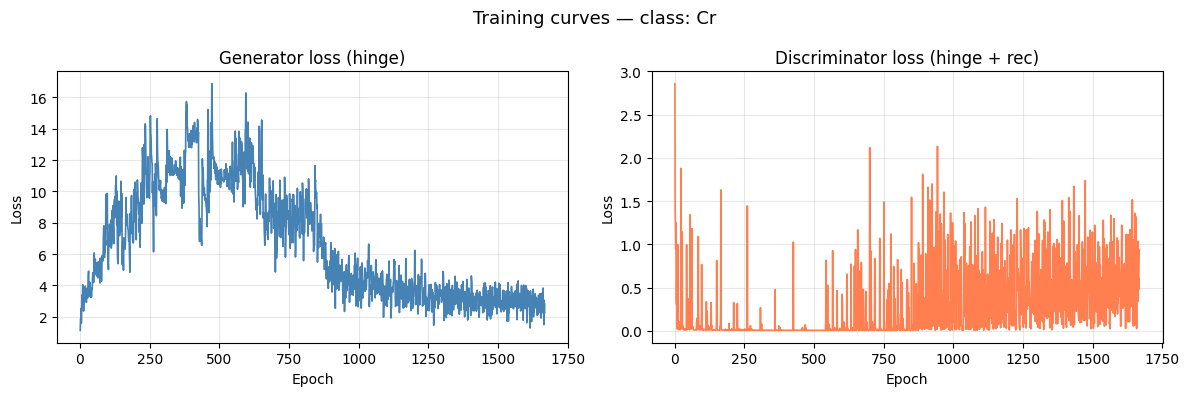

In [13]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

def plot_losses(class_name):
    log_path = LOG_ROOT / class_name / 'losses.json'
    if not log_path.exists():
        print(f'No loss log found for {class_name}. Train first.')
        return

    history = json.loads(log_path.read_text())
    epochs  = history['epoch']
    g_loss  = history['g_loss']
    d_loss  = history['d_loss']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training curves — class: {class_name}', fontsize=13)

    axes[0].plot(epochs, g_loss, color='steelblue', linewidth=1.2)
    axes[0].set_title('Generator loss (hinge)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, d_loss, color='coral', linewidth=1.2)
    axes[1].set_title('Discriminator loss (hinge + rec)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'samples/loss_curve_{class_name}.png', dpi=120)
    plt.show()

plot_losses(CLASS_TO_TRAIN)

## Training schedule for NEU defect classes

Run one class per Kaggle session if needed:

| Session | Class | Defect |
|---|---|---|
| 1 | `Cr` | Crazing |
| 2 | `In` | Inclusion |
| 3 | `Pa` | Patches |
| 4 | `PS` | Pitted surface |
| 5 | `RS` | Rolled-in scale |
| 6 | `Sc` | Scratches |

The training cell now uses `target_steps = 30000` and `max_minutes = 270`, so smaller classes automatically run more epochs while staying inside a 4-5 hour Kaggle window. Checkpoints are saved to `checkpoints/<class>/latest.pt`, and rerunning the cell resumes automatically.

After each class, run generation and visually inspect the grid. Build the final downstream dataset only after the synthetic images are usable, and keep a real-only validation/test split.
